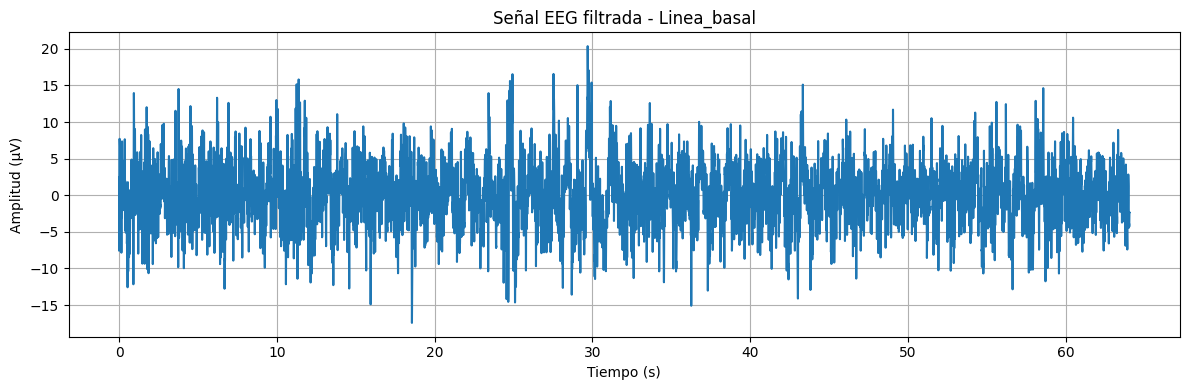

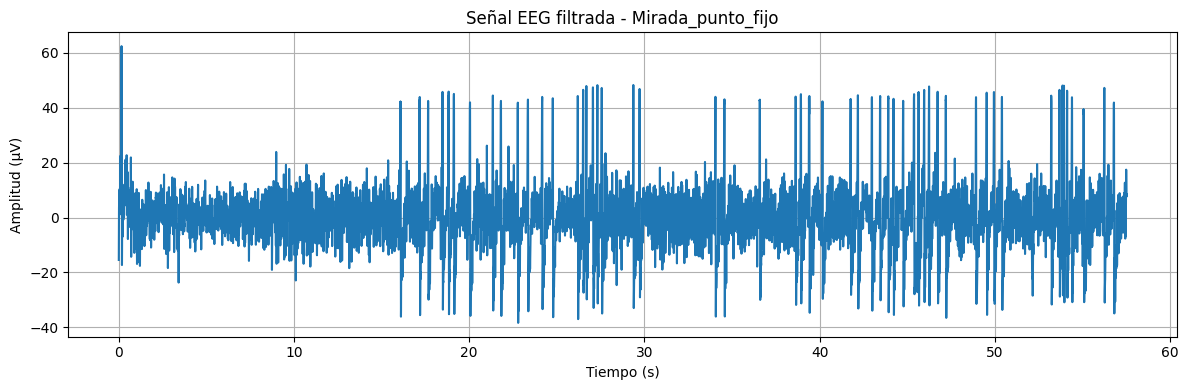

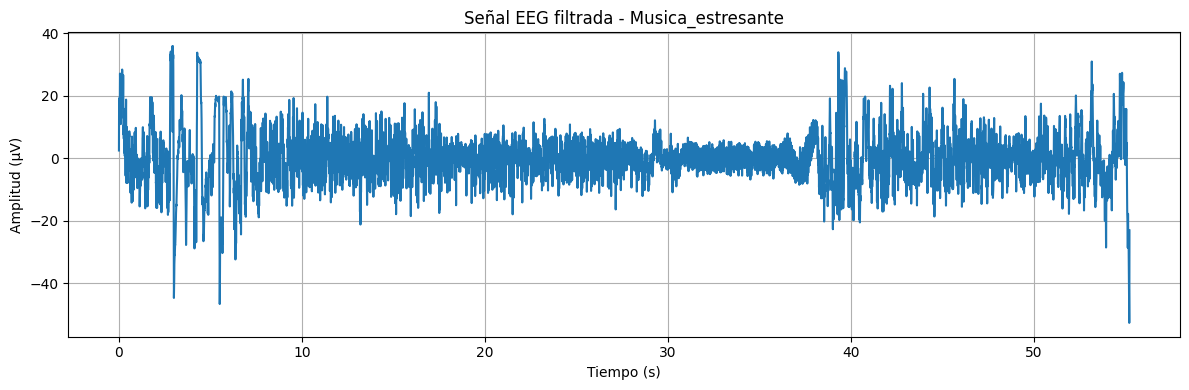

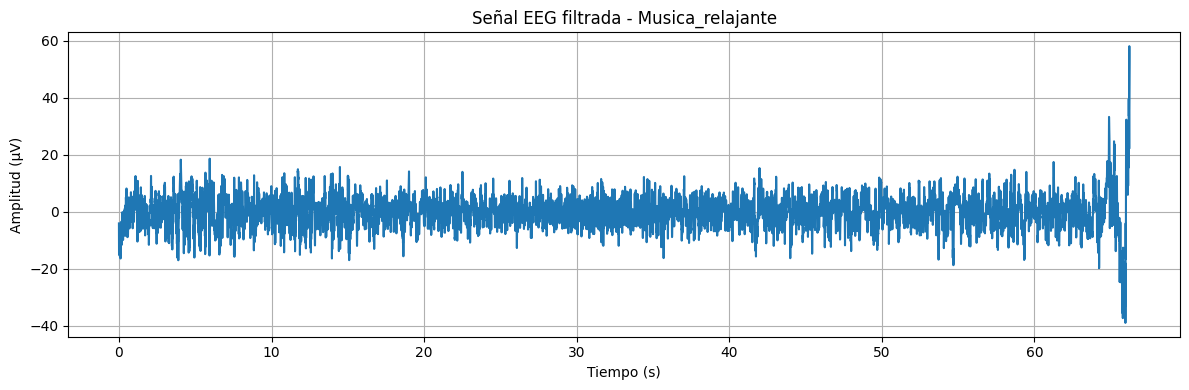

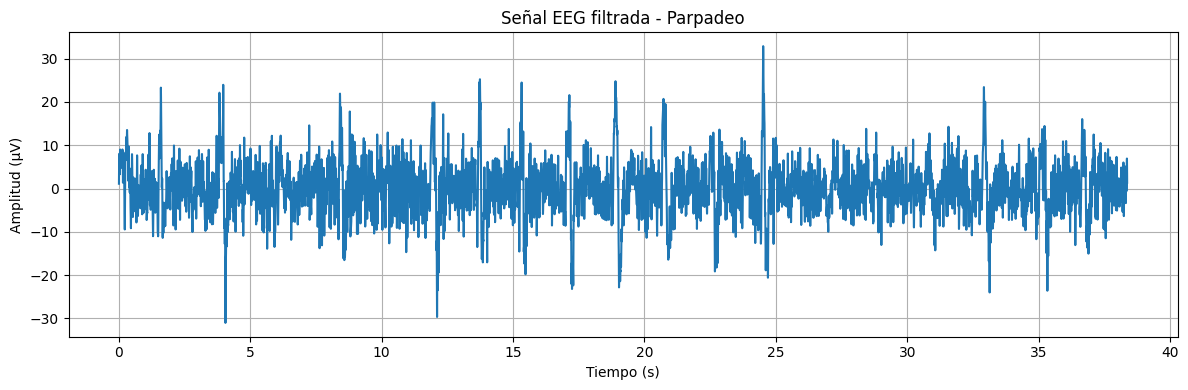

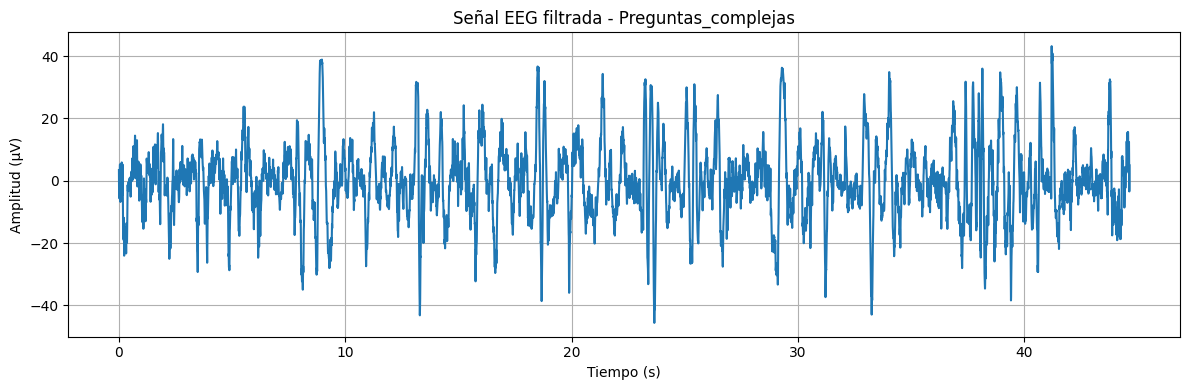

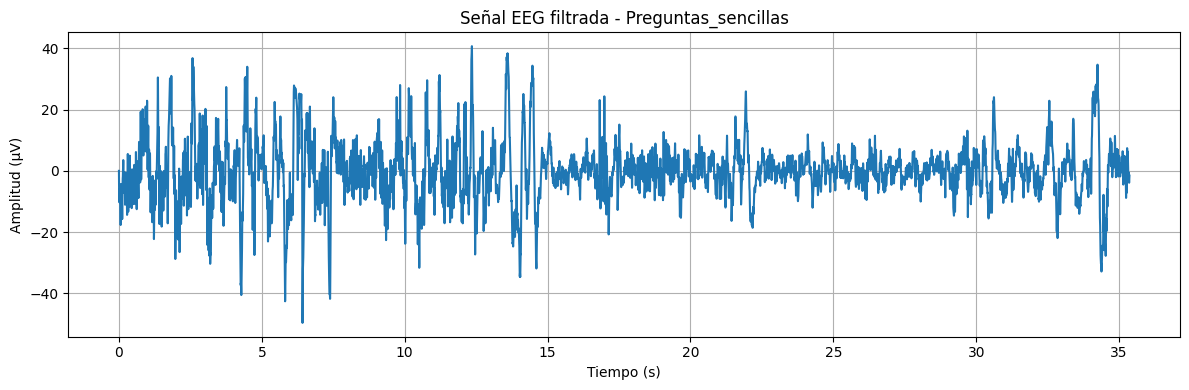

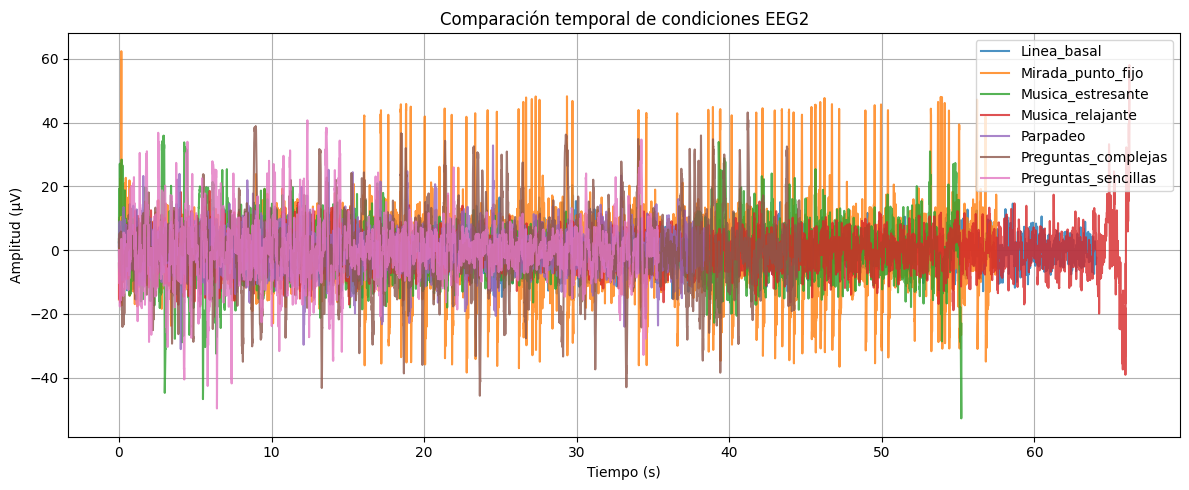

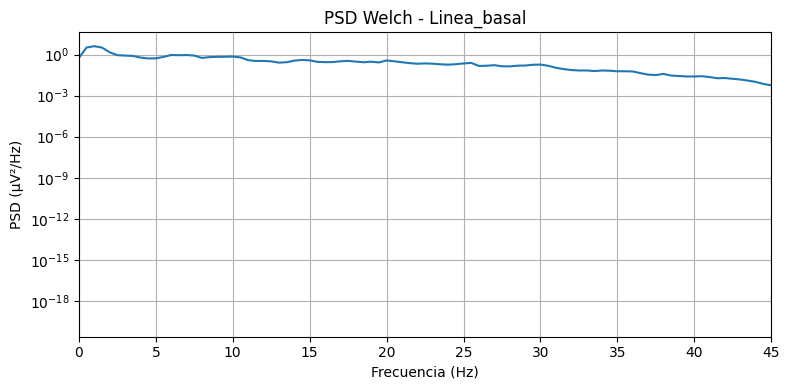

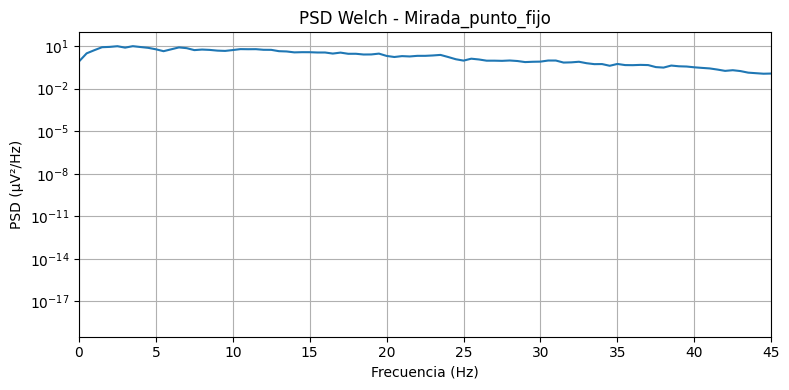

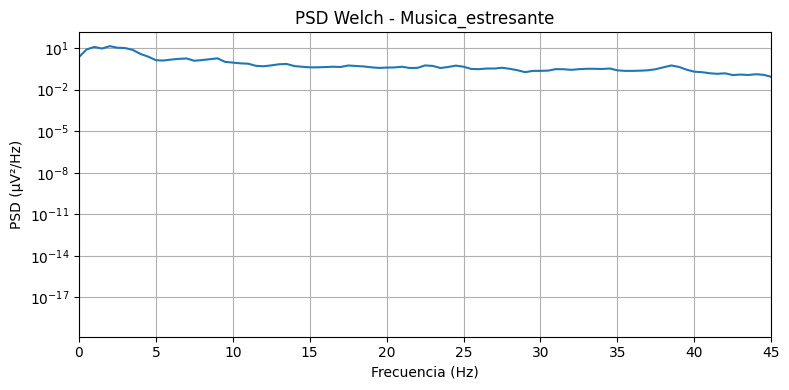

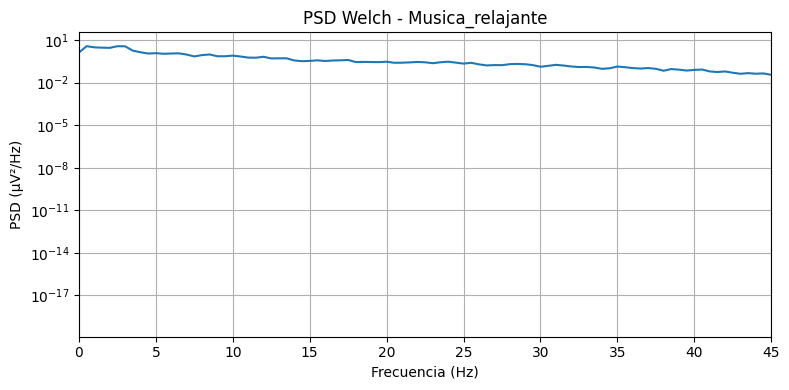

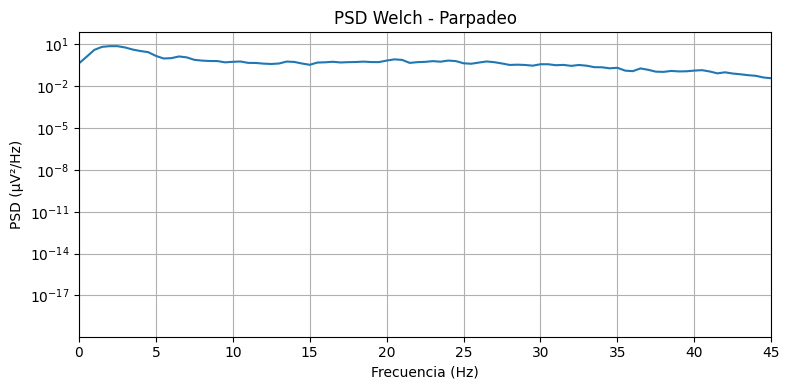

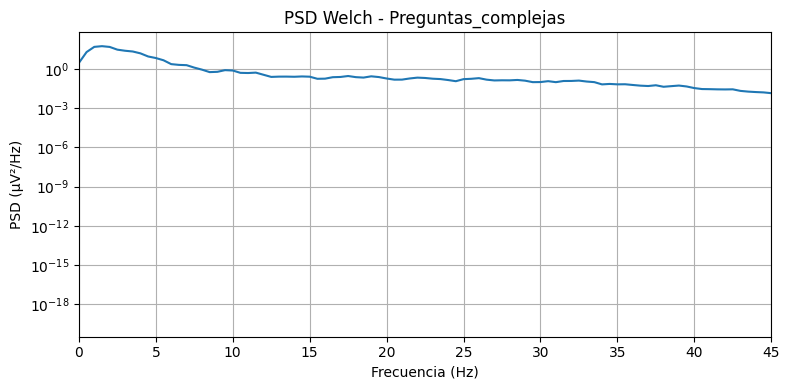

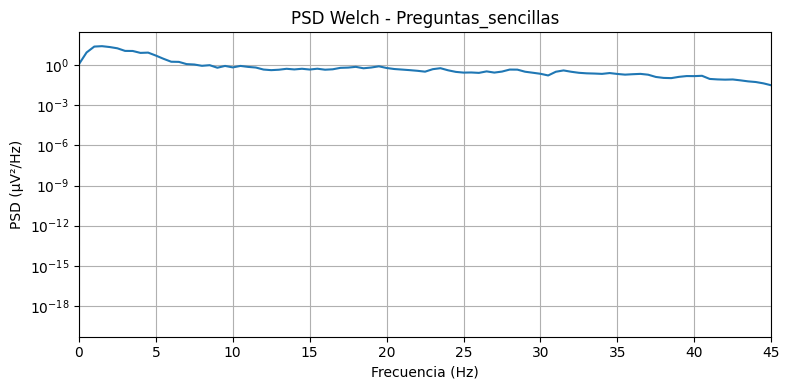

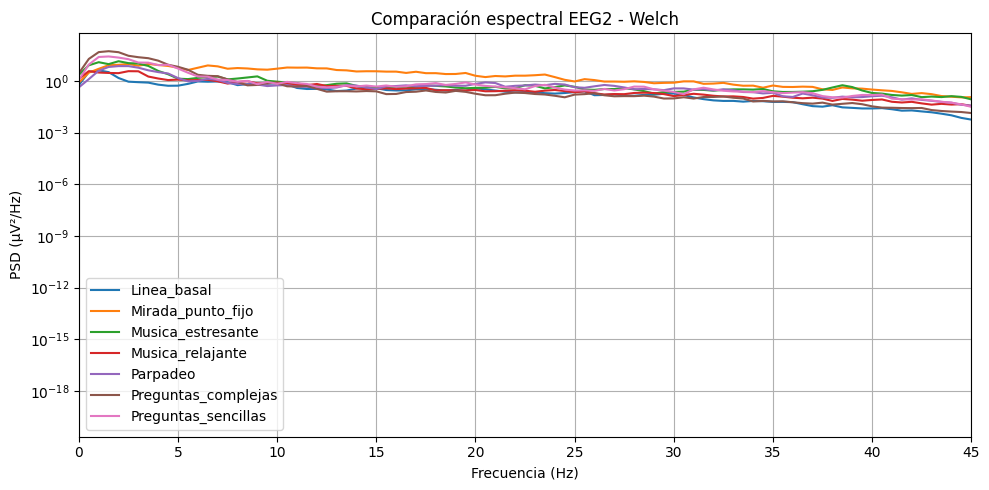

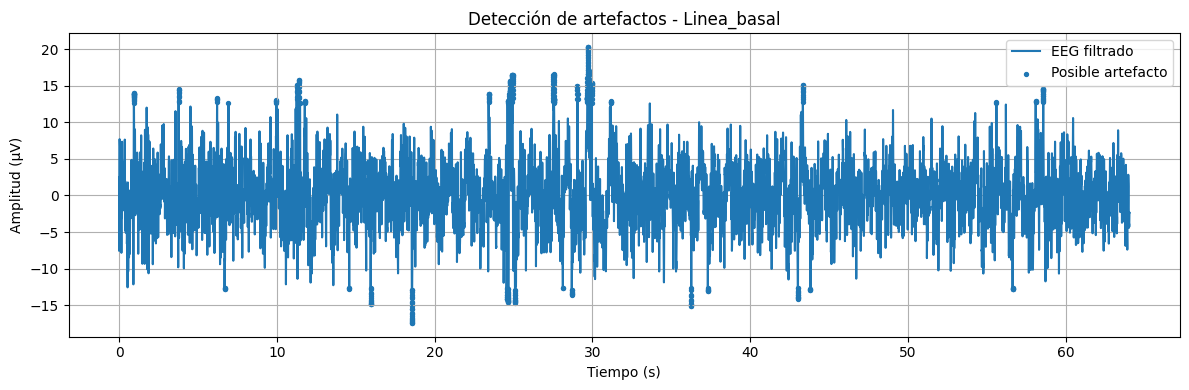

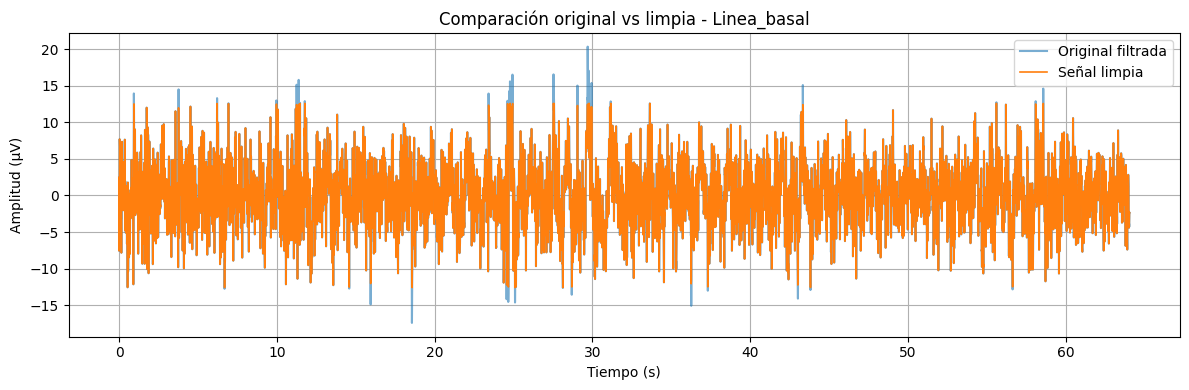

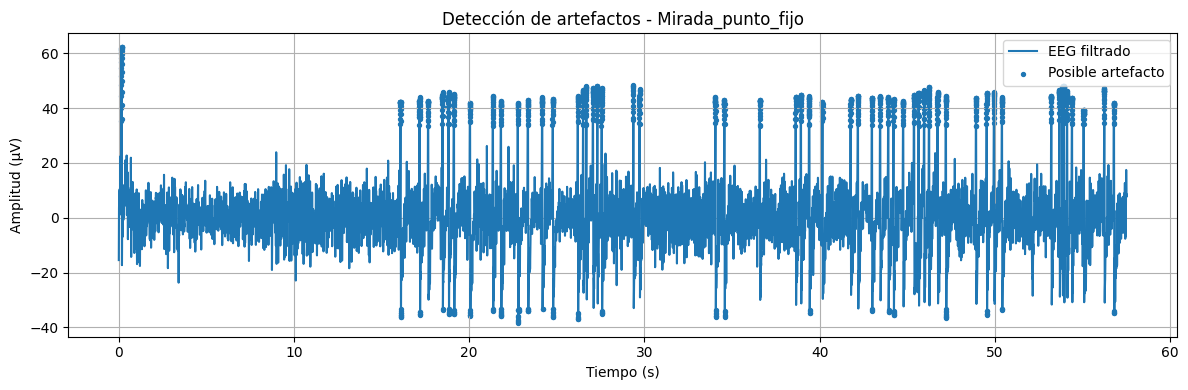

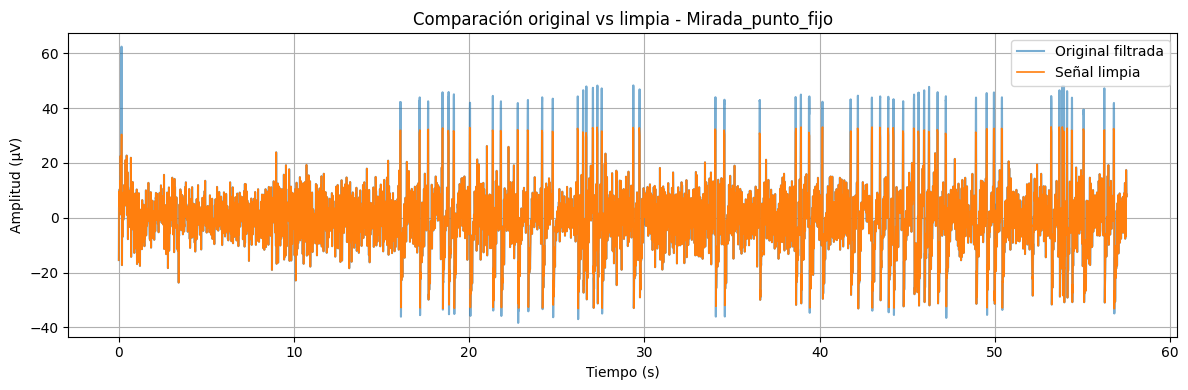

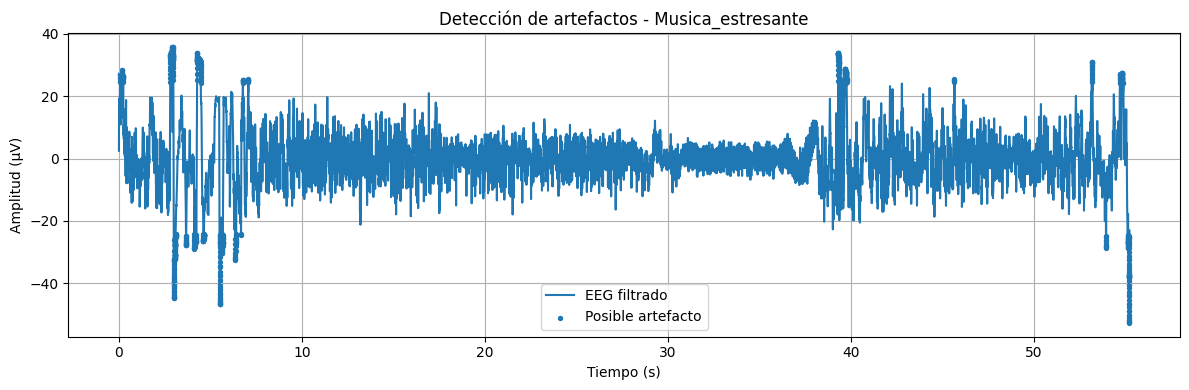

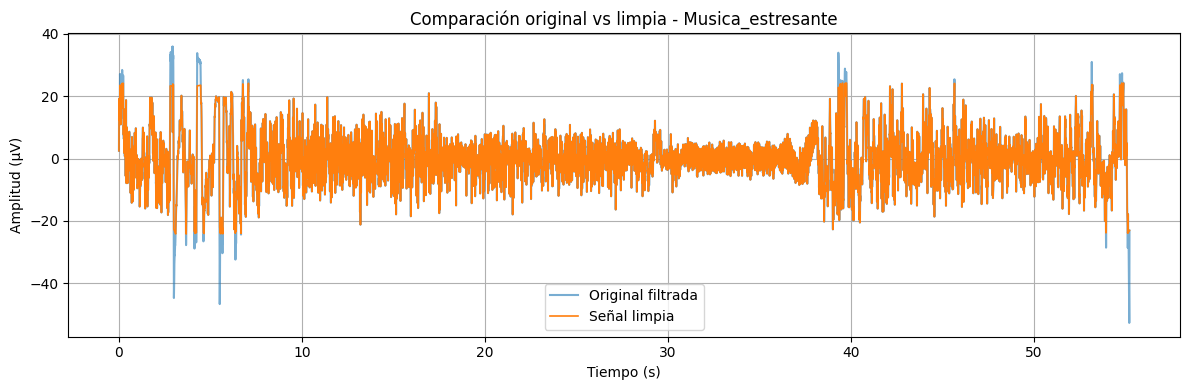

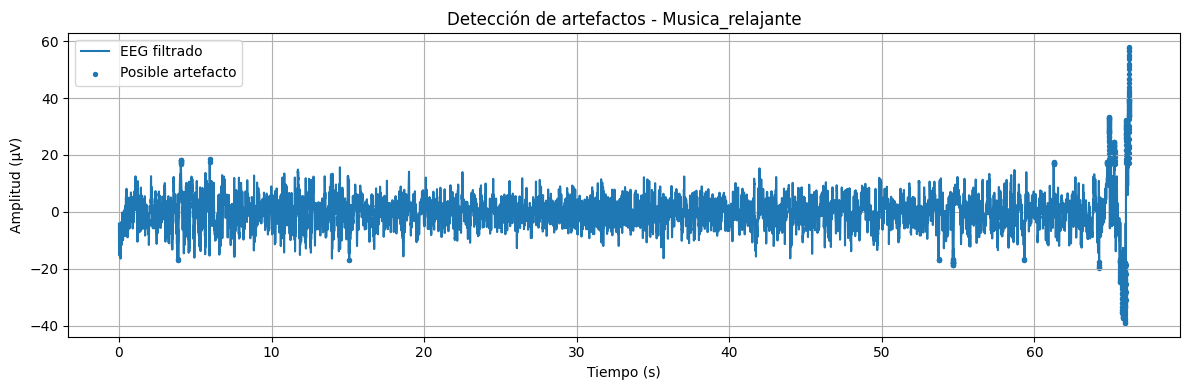

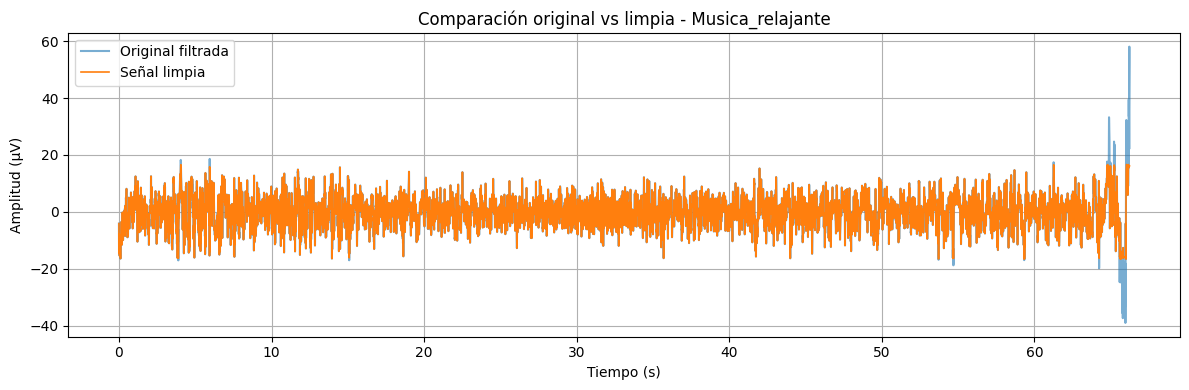

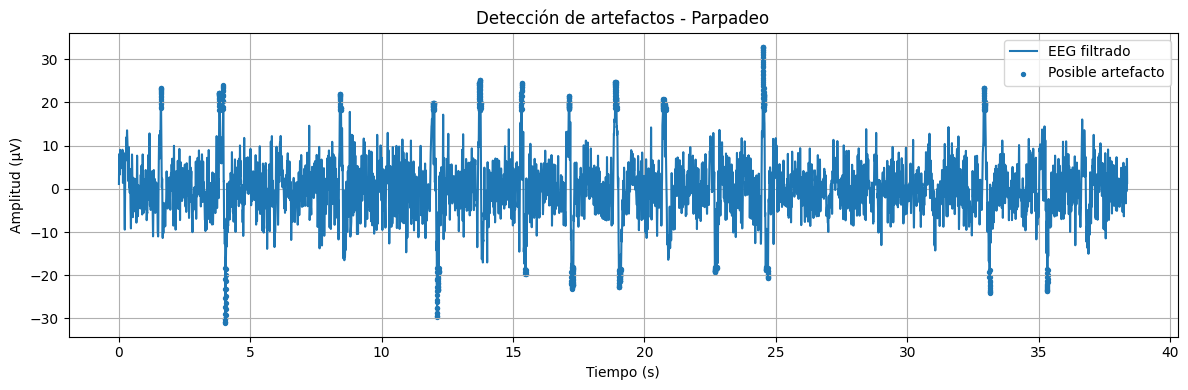

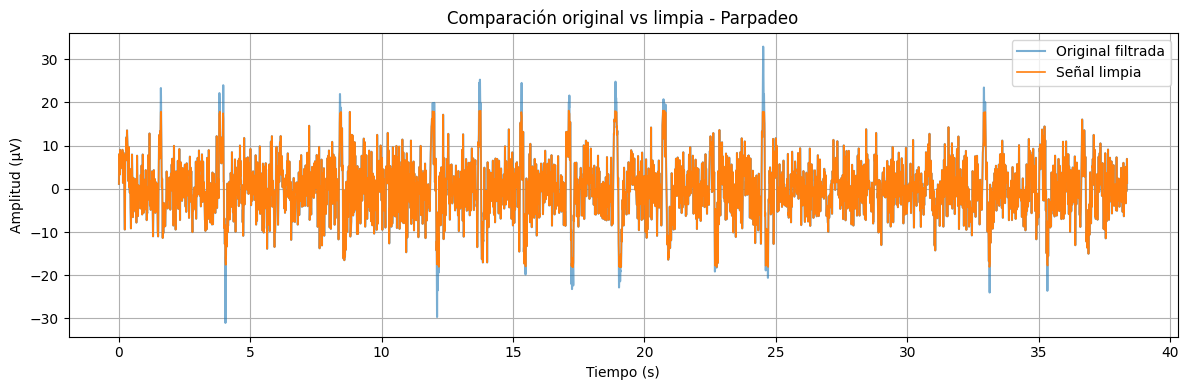

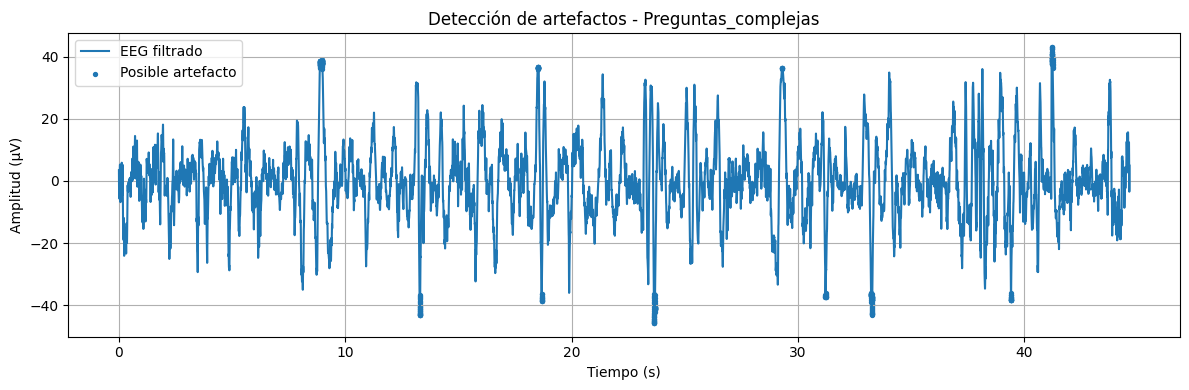

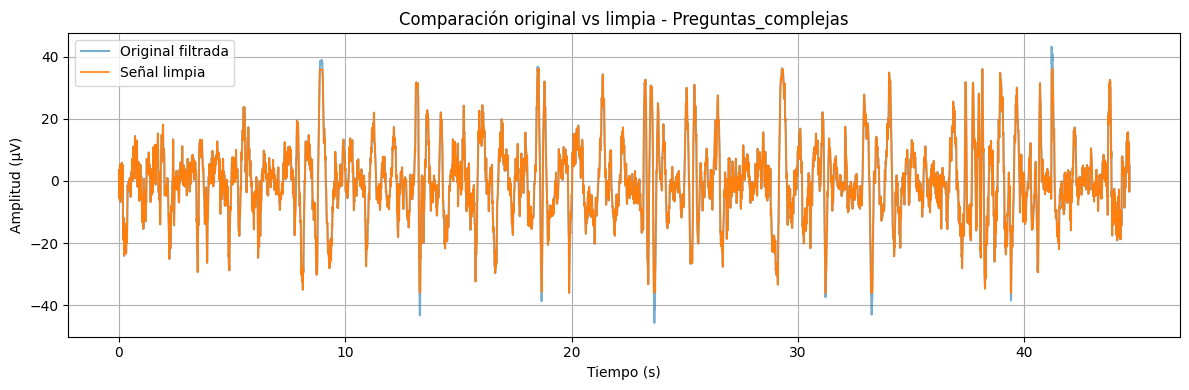

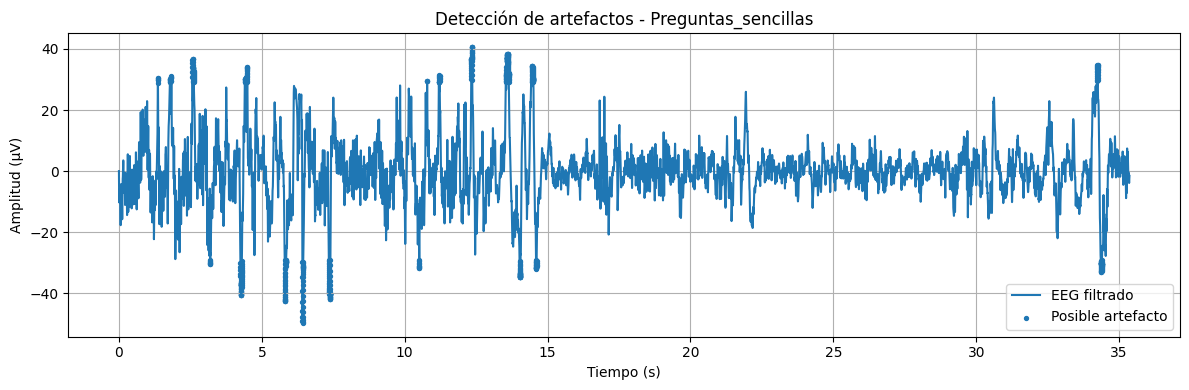

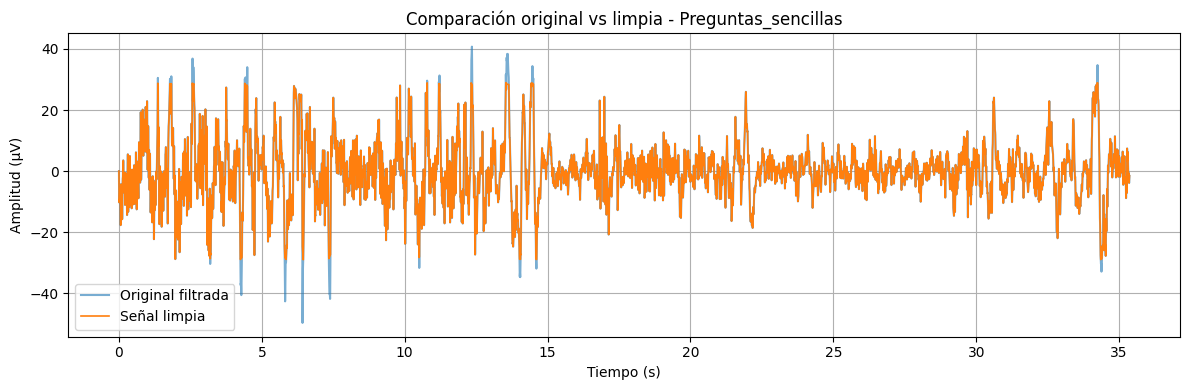

Proceso terminado. Las imágenes se guardaron en: resultados_EEG2


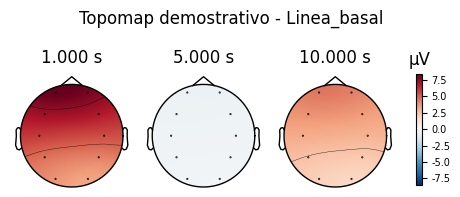

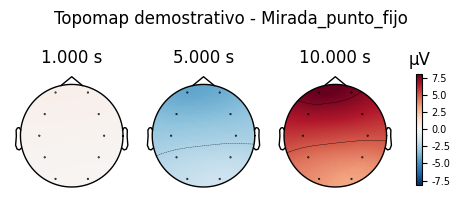

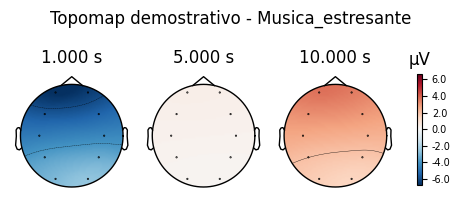

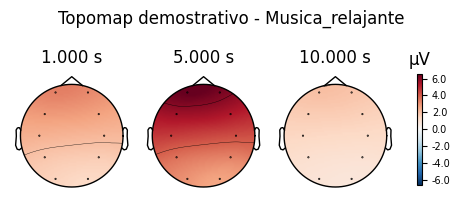

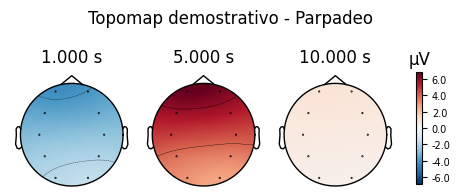

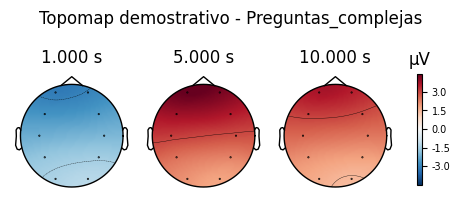

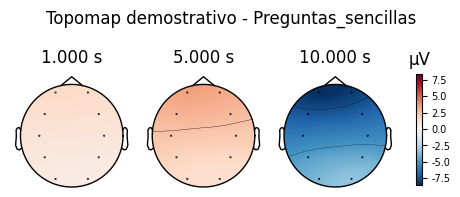

Creating RawArray with float64 data, n_channels=5, n_times=64050
    Range : 0 ... 64049 =      0.000 ...    64.049 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 3301 samples (3.301 s)

Fitting ICA to data using 5 channels (please be patient, this may take a while)
Selecting by number: 3 components
Fitting ICA took 0.4s.


TypeError: 'MNEFigure' object is not subscriptable

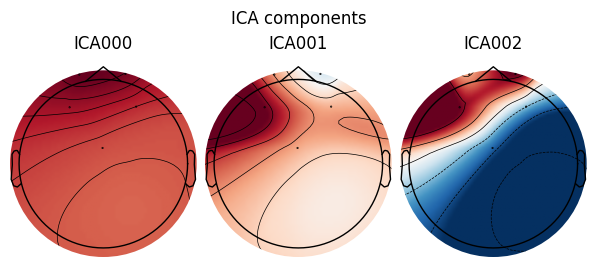

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import mne
from scipy import signal
from scipy.signal import welch

# =========================
# 1. Parámetros generales
# =========================
FS = 1000
VCC = 3.3
GAIN = 41782
BITS = 10

carpeta_salida = "resultados_EEG2"
os.makedirs(carpeta_salida, exist_ok=True)

archivos = {
    "Linea_basal": "EEG2_lineabasal1minuto.txt",
    "Mirada_punto_fijo": "EEG2_miradapuntofijo.txt",
    "Musica_estresante": "EEG2_musicaestresante.txt",
    "Musica_relajante": "EEG2_musicarelajante.txt",
    "Parpadeo": "EEG2_Parpadeo.txt",
    "Preguntas_complejas": "EEG2_preguntascomplejas.txt",
    "Preguntas_sencillas": "EEG2_Preguntassencillas.txt",
}

# =========================
# 2. Cargar y filtrar EEG
# =========================
def cargar_txt_eeg2(ruta, nombre):
    data = np.loadtxt(ruta, comments="#")
    señal_raw = data[:, -1]
    señal_raw = señal_raw[señal_raw != 0]

    señal_uv = ((señal_raw / (2**BITS)) - 0.5) * VCC / GAIN * 1e6

    b_notch, a_notch = signal.iirnotch(60, 30, FS)
    señal_f = signal.filtfilt(b_notch, a_notch, señal_uv)

    b, a = signal.butter(4, [0.5, 45], btype="bandpass", fs=FS)
    señal_f = signal.filtfilt(b, a, señal_f)

    info = mne.create_info(ch_names=["A4"], sfreq=FS, ch_types=["eeg"])
    evoked = mne.EvokedArray(señal_f[np.newaxis, :] * 1e-6, info, tmin=0)
    evoked.comment = nombre

    return evoked

evks = {}

for nombre, archivo in archivos.items():
    evks[nombre] = cargar_txt_eeg2(archivo, nombre)

# =========================
# MODALIDAD 1: Señal temporal
# =========================
for nombre, evoked in evks.items():
    señal = evoked.data[0] * 1e6
    t = evoked.times

    plt.figure(figsize=(12, 4))
    plt.plot(t, señal)
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud (µV)")
    plt.title(f"Señal EEG filtrada - {nombre}")
    plt.grid()
    plt.tight_layout()
    plt.savefig(f"{carpeta_salida}/01_temporal_{nombre}.png", dpi=300)
    plt.show()

# Comparación temporal
plt.figure(figsize=(12, 5))

for nombre, evoked in evks.items():
    señal = evoked.data[0] * 1e6
    t = evoked.times
    plt.plot(t, señal, label=nombre, alpha=0.8)

plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (µV)")
plt.title("Comparación temporal de condiciones EEG2")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(f"{carpeta_salida}/01_comparacion_temporal.png", dpi=300)
plt.show()

# =========================
# MODALIDAD 2: Welch / PSD
# =========================
for nombre, evoked in evks.items():
    señal = evoked.data[0] * 1e6

    f, psd = welch(
        señal,
        fs=FS,
        nperseg=FS*2,
        noverlap=FS
    )

    plt.figure(figsize=(8, 4))
    plt.semilogy(f, psd)
    plt.xlim(0, 45)
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("PSD (µV²/Hz)")
    plt.title(f"PSD Welch - {nombre}")
    plt.grid()
    plt.tight_layout()
    plt.savefig(f"{carpeta_salida}/02_welch_{nombre}.png", dpi=300)
    plt.show()

# Comparación Welch
plt.figure(figsize=(10, 5))

for nombre, evoked in evks.items():
    señal = evoked.data[0] * 1e6
    f, psd = welch(señal, fs=FS, nperseg=FS*2, noverlap=FS)
    plt.semilogy(f, psd, label=nombre)

plt.xlim(0, 45)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD (µV²/Hz)")
plt.title("Comparación espectral EEG2 - Welch")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(f"{carpeta_salida}/02_comparacion_welch.png", dpi=300)
plt.show()

# =========================
# MODALIDAD 3: Artefactos y limpieza
# =========================
evks_limpios = {}

for nombre, evoked in evks.items():
    señal = evoked.data[0] * 1e6
    t = evoked.times

    umbral = 3 * np.std(señal)
    artefactos = np.abs(señal) > umbral

    señal_limpia = señal.copy()

    if np.sum(~artefactos) > 0:
        señal_limpia[artefactos] = np.interp(
            t[artefactos],
            t[~artefactos],
            señal[~artefactos]
        )

    data_v = señal_limpia[np.newaxis, :] * 1e-6
    evks_limpios[nombre] = mne.EvokedArray(data_v, evoked.info, tmin=0)
    evks_limpios[nombre].comment = nombre

    plt.figure(figsize=(12, 4))
    plt.plot(t, señal, label="EEG filtrado")
    plt.scatter(t[artefactos], señal[artefactos], s=8, label="Posible artefacto")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud (µV)")
    plt.title(f"Detección de artefactos - {nombre}")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig(f"{carpeta_salida}/03_artefactos_{nombre}.png", dpi=300)
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(t, señal, label="Original filtrada", alpha=0.6)
    plt.plot(t, señal_limpia, label="Señal limpia", linewidth=1.2)
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud (µV)")
    plt.title(f"Comparación original vs limpia - {nombre}")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig(f"{carpeta_salida}/03_limpieza_{nombre}.png", dpi=300)
    plt.show()

print("Proceso terminado. Las imágenes se guardaron en:", carpeta_salida)

# =========================
# MODALIDAD 4: Topomap demostrativo
# =========================

# Como solo hay 1 canal real, se crean canales ficticios alrededor
# para poder generar un gráfico topográfico visual.

posiciones = {
    "Fp1": [-0.03, 0.08, 0.0],
    "Fp2": [0.03, 0.08, 0.0],
    "F3": [-0.05, 0.04, 0.0],
    "F4": [0.05, 0.04, 0.0],
    "C3": [-0.06, 0.00, 0.0],
    "C4": [0.06, 0.00, 0.0],
    "P3": [-0.05, -0.04, 0.0],
    "P4": [0.05, -0.04, 0.0],
    "O1": [-0.03, -0.08, 0.0],
    "O2": [0.03, -0.08, 0.0],
}

montage = mne.channels.make_dig_montage(
    ch_pos=posiciones,
    coord_frame="head"
)

for nombre, evoked in evks.items():
    señal = evoked.data[0]

    # Se replica la señal real con pequeñas variaciones artificiales
    datos_multi = np.vstack([
        señal * 1.00,
        señal * 0.95,
        señal * 0.85,
        señal * 0.80,
        señal * 0.70,
        señal * 0.65,
        señal * 0.55,
        señal * 0.50,
        señal * 0.45,
        señal * 0.40,
    ])

    info_multi = mne.create_info(
        ch_names=list(posiciones.keys()),
        sfreq=FS,
        ch_types=["eeg"] * 10
    )

    evoked_multi = mne.EvokedArray(datos_multi, info_multi, tmin=0)
    evoked_multi.set_montage(montage)

    fig = evoked_multi.plot_topomap(
        times=[1, 5, 10],
        ch_type="eeg",
        time_unit="s",
        show=False
    )

    fig.suptitle(f"Topomap demostrativo - {nombre}")
    fig.savefig(f"{carpeta_salida}/04_topomap_{nombre}.png", dpi=300)
    plt.show()

# =========================
# MODALIDAD 5: ICA demostrativo
# =========================

from mne.preprocessing import ICA

for nombre, evoked in evks.items():
    señal = evoked.data[0]

    datos_multi = np.vstack([
        señal * 1.00,
        señal * 0.95 + np.random.normal(0, 0.000001, len(señal)),
        señal * 0.85 + np.random.normal(0, 0.000001, len(señal)),
        señal * 0.75 + np.random.normal(0, 0.000001, len(señal)),
        señal * 0.65 + np.random.normal(0, 0.000001, len(señal)),
    ])

    ch_names = ["Fp1", "Fp2", "F3", "F4", "Cz"]

    info_ica = mne.create_info(
        ch_names=ch_names,
        sfreq=FS,
        ch_types=["eeg"] * len(ch_names)
    )

    raw_demo = mne.io.RawArray(datos_multi, info_ica)
    raw_demo.set_montage("standard_1020")

    raw_demo.filter(1, 45)

    ica = ICA(
        n_components=3,
        random_state=97,
        max_iter="auto"
    )

    ica.fit(raw_demo)

    fig = ica.plot_components(show=False)
    fig[0].suptitle(f"ICA demostrativo - {nombre}")
    fig[0].savefig(f"{carpeta_salida}/05_ica_componentes_{nombre}.png", dpi=300)
    plt.show()

    fig = ica.plot_sources(raw_demo, show=False)
    fig.savefig(f"{carpeta_salida}/05_ica_fuentes_{nombre}.png", dpi=300)
    plt.show()
# =========================
# TOPOMAP DEMOSTRATIVO
# =========================

import os
import numpy as np
import matplotlib.pyplot as plt
import mne

carpeta_salida = "resultados_EEG2"
os.makedirs(carpeta_salida, exist_ok=True)

ch_names = ["Fp1", "Fp2", "F3", "F4", "C3", "C4", "P3", "P4", "O1", "O2"]

for nombre, evoked in evks.items():

    señal = evoked.data[0]

    datos_topomap = np.vstack([
        señal * 1.00,
        señal * 0.95,
        señal * 0.85,
        señal * 0.80,
        señal * 0.70,
        señal * 0.65,
        señal * 0.55,
        señal * 0.50,
        señal * 0.45,
        señal * 0.40
    ])

    info_topo = mne.create_info(
        ch_names=ch_names,
        sfreq=FS,
        ch_types=["eeg"] * len(ch_names)
    )

    evoked_topo = mne.EvokedArray(datos_topomap, info_topo, tmin=0)
    evoked_topo.set_montage("standard_1020")

    fig = evoked_topo.plot_topomap(
        times=[1, 5, 10],
        ch_type="eeg",
        time_unit="s",
        show=False
    )

    fig.suptitle(f"Topomap demostrativo - {nombre}")
    fig.savefig(f"{carpeta_salida}/topomap_{nombre}.png", dpi=300)
    plt.show()